# Laboratório Didático: Classificação de Vinhos Italianos com K-Nearest Neighbors (KNN)

Este notebook foi estruturado para fins didáticos, dividindo o fluxo de trabalho de Machine Learning em etapas claras:
1. **Importação das Bibliotecas**
2. **Carregamento e Inspeção do Dataset**
3. **Análise Exploratória dos Dados (EDA)**
4. **Divisão em Conjuntos de Treino e Teste**
5. **Padronização das Características (Scale)**
6. **Treinamento do Modelo KNN**
7. **Avaliação do Desempenho do Modelo**
8. **Visualização da Matriz de Confusão**

## Etapa 1: Importação das Bibliotecas

Nesta primeira etapa, importamos as ferramentas essenciais:
- `pandas`: Manipulação e estruturação de dados em DataFrames.
- `matplotlib` e `seaborn`: Criação de gráficos e visualização de dados.
- `sklearn.datasets`: Para carregar o conjunto de dados nativo `load_wine`.
- `sklearn.model_selection`: Para realizar a divisão entre dados de treino e teste (`train_test_split`).
- `sklearn.preprocessing`: Para a padronização dos dados (`StandardScaler`).
- `sklearn.neighbors`: O algoritmo de classificação KNN (`KNeighborsClassifier`).
- `sklearn.metrics`: Métricas de avaliação de desempenho do modelo.

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import load_wine
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import classification_report, confusion_matrix

## Etapa 2: Carregamento do Dataset

Utilizamos a base de dados de **Vinhos Italianos** disponibilizada pelo `scikit-learn`.
- **Variáveis Independentes ($X$):** 13 características químicas dos vinhos (como teor alcoólico, acidez málica, cinzas, flavonoides, prolines, etc.).
- **Variável Dependente ($y$):** O rótulo ou tipo de vinho (classes `0`, `1` ou `2`).

In [ ]:
print("A carregar o dataset real de Vinhos Italianos...")

# Carregar o dataset nativo
wine_data = load_wine()

# Criar o DataFrame de características (X)
X = pd.DataFrame(wine_data.data, columns=wine_data.feature_names)

# Criar a Series do rótulo/alvo (y)
y = pd.Series(wine_data.target, name='Tipo_Vinho')

print(f"Tamanho da Base: {X.shape[0]} registros e {X.shape[1]} características químicas.\n")

A carregar o dataset real de Vinhos Italianos...
Tamanho da Base: 178 registros e 13 características químicas.



## Etapa 3: Análise Exploratória dos Dados (EDA)

Antes de treinar qualquer modelo, é fundamental entender a estrutura e o conteúdo das variáveis.

### 3.1. Visualizando as Primeiras Amostras das Características ($X$)

In [ ]:
# Exibir as 10 primeiras linhas das variáveis químicas
X.head(10)

,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline
0,14.23,1.71,2.43,15.6,127.0,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065.0
1,13.20,1.78,2.14,11.2,100.0,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050.0
2,13.16,2.36,2.67,18.6,101.0,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185.0
3,14.37,1.95,2.50,16.8,113.0,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480.0
4,13.24,2.59,2.87,21.0,118.0,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735.0
5,14.20,1.76,2.45,15.2,112.0,3.27,3.39,0.34,1.97,6.75,1.05,2.85,1450.0
6,14.39,1.87,2.45,14.6,96.0,2.50,2.52,0.30,1.98,5.25,1.02,3.58,1290.0
7,14.06,2.15,2.61,17.6,121.0,2.60,2.51,0.31,1.25,5.05,1.06,3.58,1295.0
8,14.83,1.64,2.17,14.0,97.0,2.80,2.98,0.29,1.98,5.20,1.08,2.85,1045.0
9,13.86,1.35,2.27,16.0,98.0,2.98,3.15,0.22,1.85,7.22,1.01,3.55,1045.0


### 3.2. Visualizando as Primeiras Amostras do Rótulo ($y$)

In [ ]:
# Exibir os 10 primeiros rótulos (classes de vinho)
y.head(10)

,Tipo_Vinho
0,0
1,0
2,0
3,0
4,0
5,0
6,0
7,0
8,0
9,0


### 3.3. Verificação do Balanceamento de Classes
Verificamos a contagem de amostras para cada tipo de vinho (0, 1 e 2) para confirmar se as classes estão bem distribuídas.

In [ ]:
# Contagem de elementos por classe
y.value_counts()

,count
Tipo_Vinho,
1,71
0,59
2,48


## Etapa 4: Divisão em Dados de Treino e Teste

Para avaliar o modelo de maneira não viesada, dividimos os dados em dois conjuntos:
- **Treino (75%):** Usado para ajustar o modelo.
- **Teste (25%):** Usado para testar a capacidade do modelo em dados não vistos.

Utilizamos `stratify=y` para garantir que a proporção das classes seja mantida em ambos os conjuntos.

In [ ]:
# Separar dados de treino e teste
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42, stratify=y
)

print(f"Quantidade de amostras de Treino: {X_train.shape[0]}")
print(f"Quantidade de amostras de Teste: {X_test.shape[0]}")

Quantidade de amostras de Treino: 133
Quantidade de amostras de Teste: 45


## Etapa 5: Padronização das Características (Feature Scaling)

**Por que padronizar é essencial no KNN?**
O algoritmo KNN baseia suas decisões na **distância euclidiana** entre os pontos de dados.
Se uma variável possui valores muito grandes (ex: `proline` varia entre 300 e 1600) e outra possui valores pequenos (ex: `nonflavanoid_phenols` varia entre 0.1 e 0.6), a variável de maior magnitude dominará o cálculo da distância.

O `StandardScaler` transforma os dados para que cada variável tenha **média 0** e **desvio padrão 1**.

In [ ]:
# Inicializar o padronizador
scaler = StandardScaler()

# Ajustar o padronizador com os dados de treino e transformá-los
X_train_scaled = scaler.fit_transform(X_train)

# Transformar os dados de teste com a mesma escala do treino
X_test_scaled = scaler.transform(X_test)

# Visualizar os 5 primeiros registros padronizados do treino
X_train_scaled[:5]

array([[ 2.33041778, -0.63796267, -0.74427132, -1.70005902, -0.20099315,
         0.82455876,  1.033603  , -0.60488012,  0.64316856,  0.08154467,
         0.57887517,  0.37385664,  0.97971254],
       [-0.57363985, -0.55510229, -1.45939437,  0.23809346, -1.00496573,
        -0.13141667, -0.07687826, -0.35083047, -0.21344488, -0.87740273,
         0.4011093 ,  1.42836362, -0.248245  ],
       [ 0.39020686, -0.63796267,  1.77747839, -1.25279306,  0.66997716,
         0.50590028,  0.71931585, -0.18146404, -0.41903211, -0.17304314,
         0.62331663,  0.27133513,  0.43651416],
       [-0.79895467, -1.2363988 , -1.57230854, -1.46151717,  2.41191776,
        -0.60940439, -0.15021193, -0.09678082,  1.97948553, -0.68221874,
         0.48999223, -0.41702359,  0.00853969],
       [ 0.23999698,  0.02492042,  1.13763145, -0.32844342,  0.06699772,
         0.82455876,  1.3059852 , -0.5201969 ,  2.06514687,  0.28521491,
         0.35666783,  0.84252641,  1.44060812]])

## Etapa 6: Treinamento do Modelo KNN

O algoritmo **K-Nearest Neighbors (KNN)** classifica um novo ponto verificando quais são os $k$ vizinhos mais próximos no espaço de características padronizado e atribuindo a classe mais frequente entre eles.

Neste exemplo, definimos $k = 5$ (`n_neighbors=5`).

In [ ]:
print("A treinar o algoritmo KNN (Mapeando distâncias)...")

# Criar o modelo KNN
knn = KNeighborsClassifier(n_neighbors=5)

# Treinar o modelo com os dados de treino padronizados
knn.fit(X_train_scaled, y_train)

A treinar o algoritmo KNN (Mapeando distâncias)...


KNeighborsClassifier()

## Etapa 7: Predição e Avaliação do Desempenho

Agora, fazemos a predição nos dados de teste (`X_test_scaled`) e comparamos as respostas com os valores reais (`y_test`).

O **Relatório de Classificação** nos mostra:
- **Precision (Precisão):** Das amostras classificadas como uma classe, quantas estavam corretas.
- **Recall (Revocação):** Das amostras reais de uma classe, quantas o modelo conseguiu identificar.
- **F1-Score:** Média harmônica entre precisão e revocação.
- **Accuracy (Acurácia):** Proporção total de acertos.

In [ ]:
# Realizar as predições no conjunto de teste
y_pred = knn.predict(X_test_scaled)

# Exibir o relatório de métricas
print("Relatório de Classificação (Tipos de Vinho: 0, 1 e 2):\n")
print(classification_report(y_test, y_pred, target_names=wine_data.target_names))

Relatório de Classificação (Tipos de Vinho: 0, 1 e 2):

              precision    recall  f1-score   support

     class_0       1.00      1.00      1.00        15
     class_1       0.94      0.89      0.91        18
     class_2       0.85      0.92      0.88        12

    accuracy                           0.93        45
   macro avg       0.93      0.94      0.93        45
weighted avg       0.94      0.93      0.93        45



## Etapa 8: Visualização da Matriz de Confusão

A **Matriz de Confusão** permite visualizar de forma gráfica os acertos (diagonal principal) e os erros de classificação do modelo entre as 3 diferentes classes de vinho.

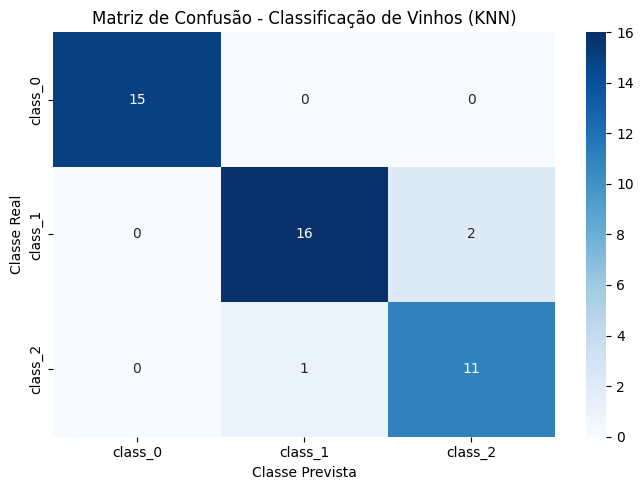

In [ ]:
# Calcular a matriz de confusão
cm = confusion_matrix(y_test, y_pred)

# Plotar gráfico de calor (Heatmap)
plt.figure(figsize=(7, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=wine_data.target_names,
            yticklabels=wine_data.target_names)

plt.title('Matriz de Confusão - Classificação de Vinhos (KNN)')
plt.xlabel('Classe Prevista')
plt.ylabel('Classe Real')
plt.tight_layout()
plt.show()


Testando o KNN para diferentes valores de K...


,K,Acurácia,Precisão (Macro),Recall (Macro)
0,1,0.955556,0.953526,0.962963
1,2,0.933333,0.935143,0.944444
2,3,0.955556,0.953526,0.962963
3,4,0.933333,0.931781,0.935185
4,5,0.933333,0.929110,0.935185
5,6,0.933333,0.931781,0.935185
6,7,0.977778,0.974359,0.981481
7,8,0.955556,0.960648,0.953704
8,9,0.977778,0.974359,0.981481
9,10,0.977778,0.974359,0.981481


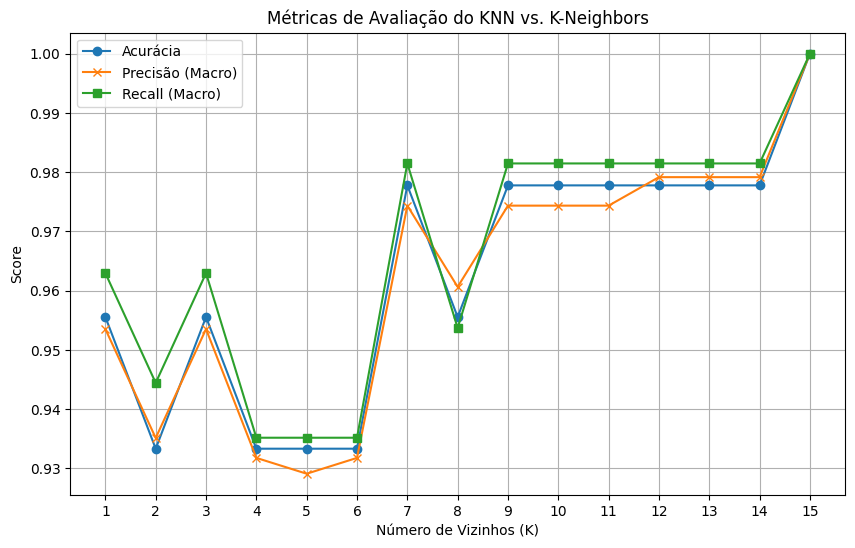

In [ ]:
from sklearn.metrics import accuracy_score, precision_score, recall_score

accuracies = []
precisions = []
recalls = []
k_values = range(1, 16)

print("\nTestando o KNN para diferentes valores de K...")

for k in k_values:
    knn_loop = KNeighborsClassifier(n_neighbors=k, metric='euclidean')
    knn_loop.fit(X_train_scaled, y_train)
    y_pred_loop = knn_loop.predict(X_test_scaled)

    acc = accuracy_score(y_test, y_pred_loop)
    prec = precision_score(y_test, y_pred_loop, average='macro', zero_division=0)
    rec = recall_score(y_test, y_pred_loop, average='macro', zero_division=0)

    accuracies.append(acc)
    precisions.append(prec)
    recalls.append(rec)

results_df = pd.DataFrame({
    'K': k_values,
    'Acurácia': accuracies,
    'Precisão (Macro)': precisions,
    'Recall (Macro)': recalls
})

display(results_df)

plt.figure(figsize=(10, 6))
plt.plot(k_values, accuracies, marker='o', label='Acurácia')
plt.plot(k_values, precisions, marker='x', label='Precisão (Macro)')
plt.plot(k_values, recalls, marker='s', label='Recall (Macro)')
plt.title('Métricas de Avaliação do KNN vs. K-Neighbors')
plt.xlabel('Número de Vizinhos (K)')
plt.ylabel('Score')
plt.xticks(k_values)
plt.grid(True)
plt.legend()
plt.show()